In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
pd.set_option('display.max_row',111)
pd.set_option('display.max_column',111)

In [5]:
link='/kaggle/input/covid19/dataset.xlsx'
data=pd.read_excel(link)
df=data.copy()

In [ ]:
df

# 3. Pre-processing
**Objectif** : Transformer le dataset pour le préparer au Machine Learning

* **Objectif 1: mettre les données dans un format propice au ML**
    * Train / Test
    * Encodage
    * Nettoyage des NaN

--> premier modèle : évaluation - diagnostic

* **Objectif 2 : améliorer la performance du modèle**
    * Feature Selection
    * Feature Engineering
    * Feature Scaling
    * Suppression des Outliers

## **Création des sous-ensembles (suite au EDA)**

In [6]:
target_feature='SARS-Cov-2 exam result'
missing_rate=df.isna().sum()/df.shape[0]

blood_columns=list(df.columns[(missing_rate>0.88)&(missing_rate<0.9)])
viral_columns=list(df.columns[(missing_rate>0.75)&(missing_rate<0.80)])

key_columns=['Patient age quantile',target_feature]

In [7]:
df=df[key_columns+blood_columns+viral_columns]
df.head()

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


## **Traintest**

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
trainset,testset=train_test_split(df,test_size=0.2,random_state=42)

In [10]:
print(f'Les proportions de {target_feature} dans le trainset sont :\n')
trainset[target_feature].value_counts()

Les proportions de SARS-Cov-2 exam result dans le trainset sont :



SARS-Cov-2 exam result
negative    4065
positive     450
Name: count, dtype: int64

In [11]:
print(f'Les proportions de {target_feature} dans le testset sont :\n')
testset[target_feature].value_counts()

Les proportions de SARS-Cov-2 exam result dans le testset sont :



SARS-Cov-2 exam result
negative    1021
positive     108
Name: count, dtype: int64

## **Encodage**

In [12]:
def encodage(df):
    code={'positive':1,
     'negative':0,
     'detected':1,
     'not_detected':0}
    
    for col in df.select_dtypes('object'):
        df[col]=df[col].map(code)
    return df

In [13]:
def feature_engineering(df):
    df['est malade']=df[viral_columns].sum(axis=1)>=1
    df=df.drop(viral_columns,axis=1)
    return df

In [14]:
def imputation(df):
    #df['is na']=(df['Parainfluenza 3'].isna()) | (df['Leukocytes'].isna()) #ou
    #df.fillna(-999)
    df=df.dropna(axis=0)
    return df

In [15]:
def preprocessing(df):
    df=encodage(df)
    df=feature_engineering(df)
    df=imputation(df)

    X=df.drop(target_feature,axis=1)
    y=df[target_feature]

    print(y.value_counts())

    return X,y

In [16]:
X_train,y_train=preprocessing(trainset)

SARS-Cov-2 exam result
0    419
1     65
Name: count, dtype: int64


In [17]:
X_test,y_test=preprocessing(testset)

SARS-Cov-2 exam result
0    98
1    16
Name: count, dtype: int64


## **Modelisation**

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

In [141]:
#model=RandomForestClassifier(random_state=42)
model=make_pipeline(PolynomialFeatures(2),SelectKBest(f_classif,k=10), #on prend les 10 best variables
                    RandomForestClassifier(random_state=42))

## **Procédure d'évaluation**

In [19]:
from sklearn.metrics import f1_score,confusion_matrix,classification_report
from sklearn.model_selection import learning_curve

In [20]:
def evaluation(model):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))

    N,train_score,val_score=learning_curve(model,X_train,y_train,
                                            cv=4,scoring='f1',
                                            train_sizes=np.linspace(0.1,1,10))
    plt.figure(figsize=(12,8))
    plt.plot(N,train_score.mean(axis=1),label='train score')
    plt.plot(N,val_score.mean(axis=1),label='validation score')
    plt.legend()
    

[[95  3]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        98
           1       0.67      0.38      0.48        16

    accuracy                           0.89       114
   macro avg       0.79      0.67      0.71       114
weighted avg       0.87      0.89      0.87       114



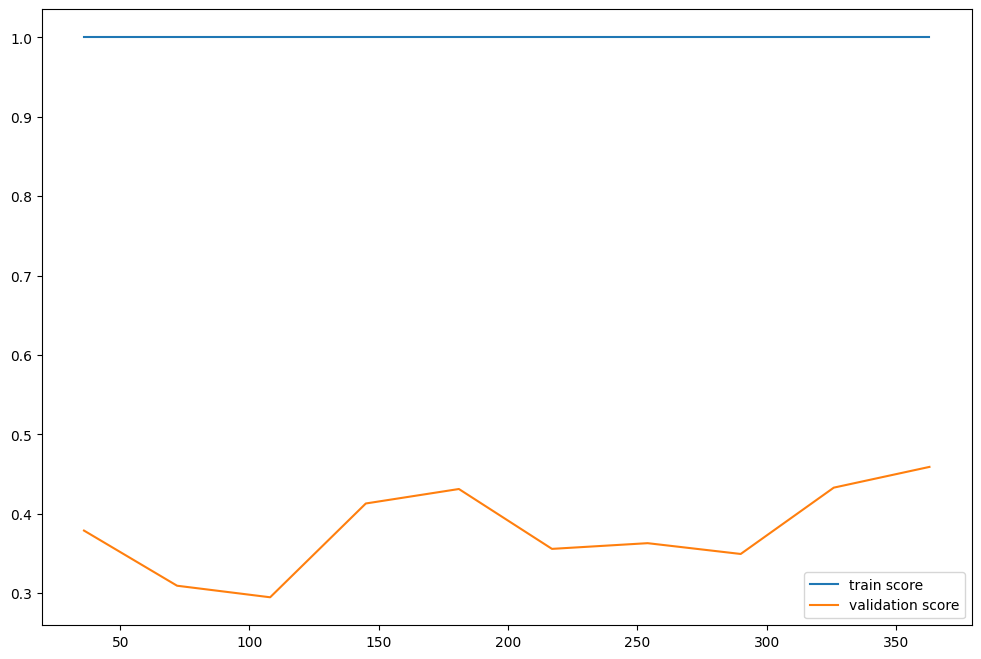

In [142]:
evaluation(model)

## **Feature importances**

<Axes: >

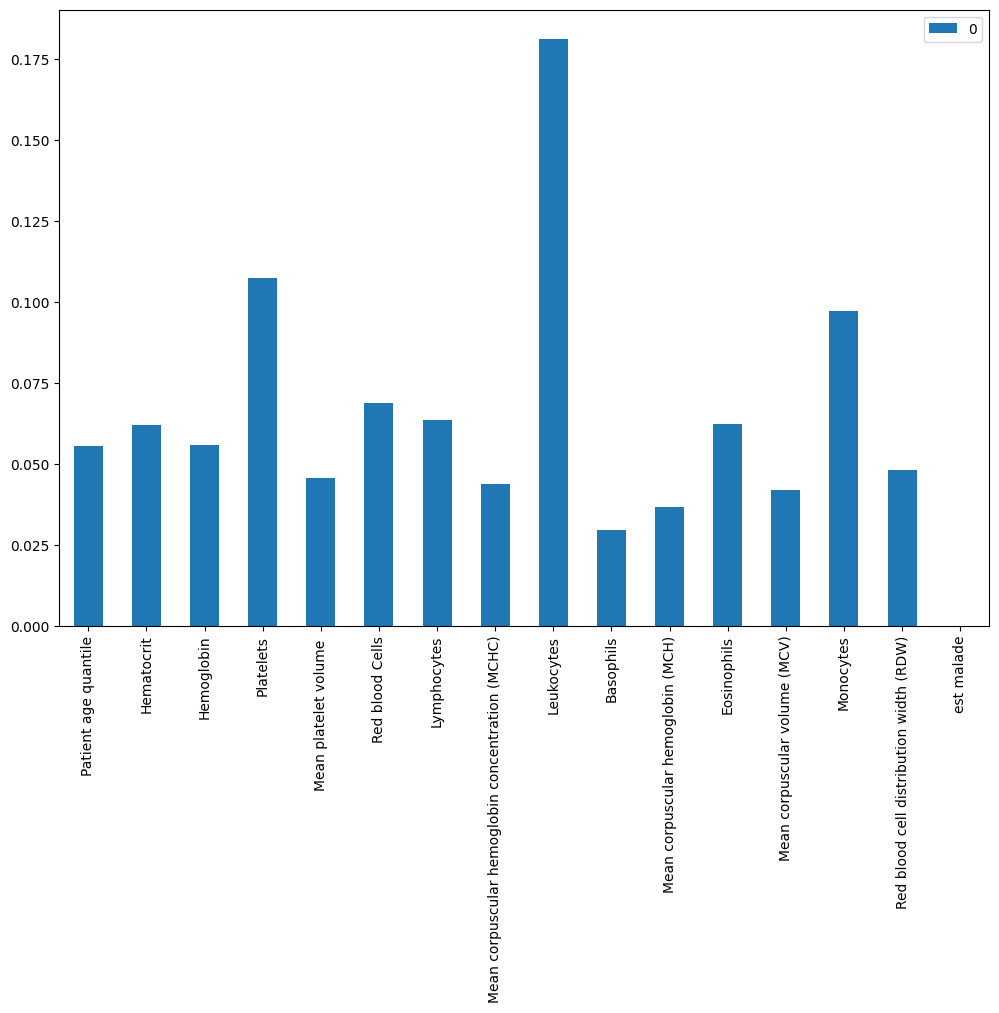

In [140]:
pd.DataFrame(model.feature_importances_,index=X_train.columns).plot.bar(figsize=(12,8))

# 4. Modelling
**Objectif** : développer un modèle de Machine Learning
 qui réponde à l'objectif final
 
* Définir une fonction d'évaluation
* Entrainement de différents modèles
* Optimisation avec GridSearchCV
* (Optionnel) Analyse des erreurs et retour au Preprocessing/EDA
* Learning Curve et prise de décision

## **Entrainement de différents modèles**

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [26]:
preprocessor=make_pipeline(PolynomialFeatures(2,include_bias=False),
                           SelectKBest(f_classif,k=10), #on prend les 10 best variables
                    )

In [23]:
RandomForest=make_pipeline(preprocessor,RandomForestClassifier(random_state=42))
AdaBoost=make_pipeline(preprocessor, AdaBoostClassifier(random_state=42))
SVM=make_pipeline(preprocessor,StandardScaler(),SVC(random_state=42))
KNN=make_pipeline(preprocessor,StandardScaler(),KNeighborsClassifier())

In [31]:
list_of_models={'RandomForest':RandomForest,
                'AdaBoost':AdaBoost,
                'SVM':SVM,
                'KNN':KNN}

RandomForest
[[95  3]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        98
           1       0.70      0.44      0.54        16

    accuracy                           0.89       114
   macro avg       0.81      0.70      0.74       114
weighted avg       0.88      0.89      0.88       114

AdaBoost
[[92  6]
 [ 7  9]]
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        98
           1       0.60      0.56      0.58        16

    accuracy                           0.89       114
   macro avg       0.76      0.75      0.76       114
weighted avg       0.88      0.89      0.88       114

SVM
[[97  1]
 [ 8  8]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.96        98
           1       0.89      0.50      0.64        16

    accuracy                           0.92       114
   macro avg       0.91      0.74      0.80  

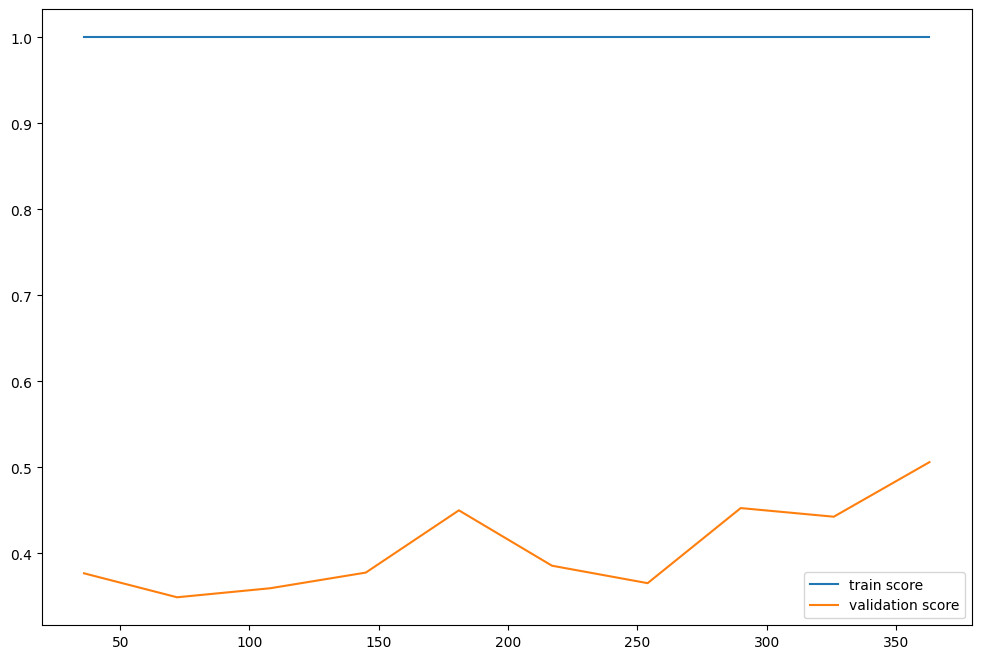

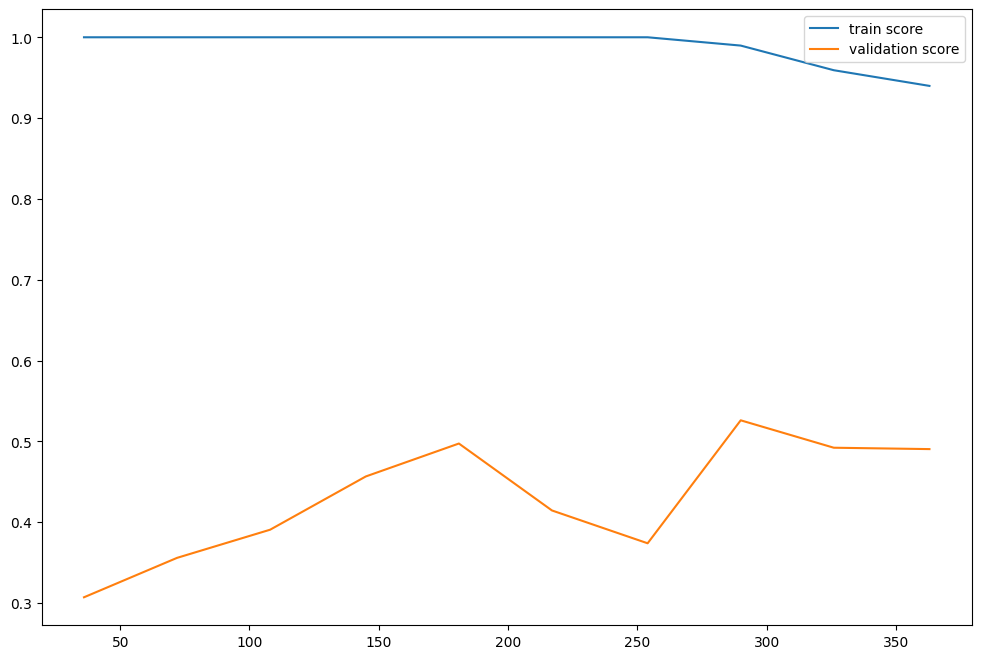

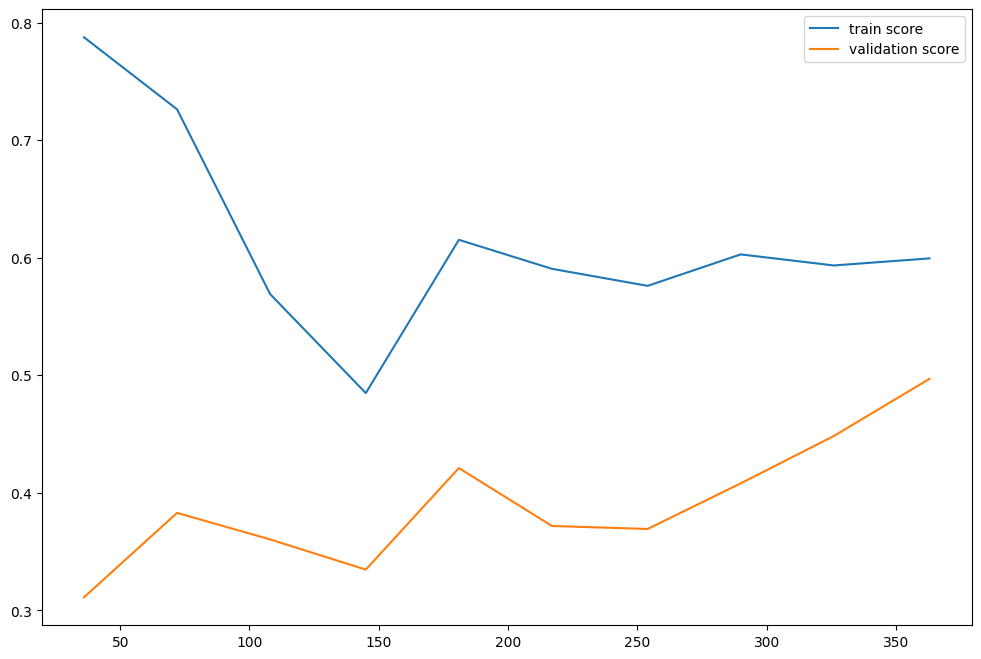

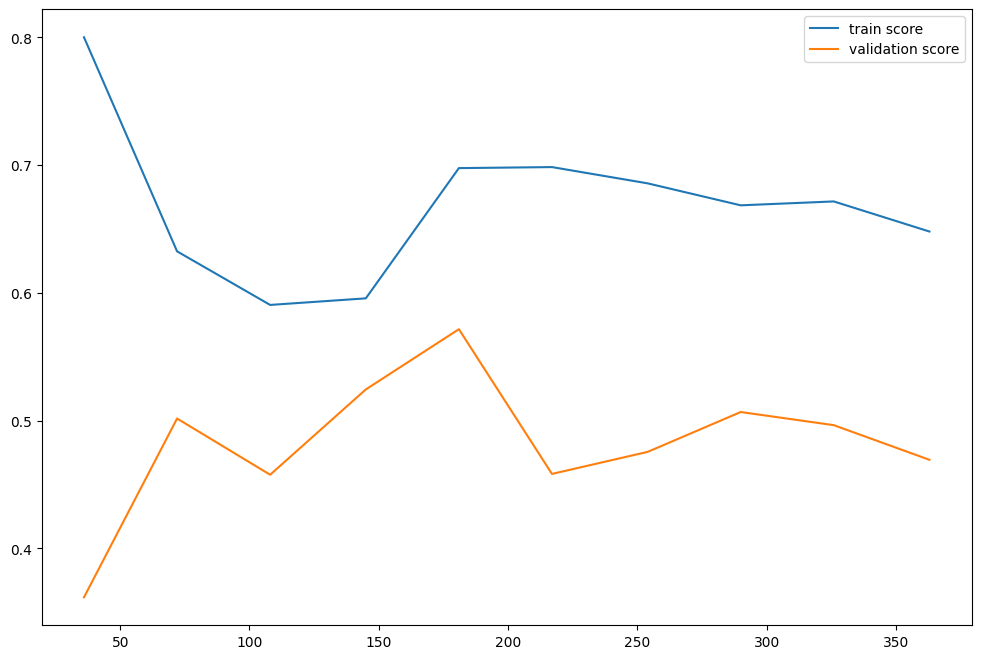

In [33]:
for name,model in list_of_models.items():
    print(name)
    evaluation(model)

## **Optimisation**

In [42]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [35]:
SVM

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                                 ('selectkbest', SelectKBest())])),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=42))])

In [46]:
hyper_params={'svc__gamma':[1e-3,1e-4],
              'svc__C':[1,10,100,1000],
             'pipeline__polynomialfeatures__degree':[2,3,4],
             'pipeline__selectkbest__k':range(40,60)}

In [47]:
grid=RandomizedSearchCV(SVM,hyper_params,scoring='recall',cv=4,
                        n_iter=40)
grid.fit(X_train,y_train)
print(grid.best_params_)
y_pred=grid.predict(X_test)
print(classification_report(y_test,y_pred))

{'svc__gamma': 0.001, 'svc__C': 1000, 'pipeline__selectkbest__k': 56, 'pipeline__polynomialfeatures__degree': 4}
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        98
           1       0.71      0.62      0.67        16

    accuracy                           0.91       114
   macro avg       0.83      0.79      0.81       114
weighted avg       0.91      0.91      0.91       114



[[96  2]
 [ 7  9]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        98
           1       0.82      0.56      0.67        16

    accuracy                           0.92       114
   macro avg       0.88      0.77      0.81       114
weighted avg       0.92      0.92      0.91       114



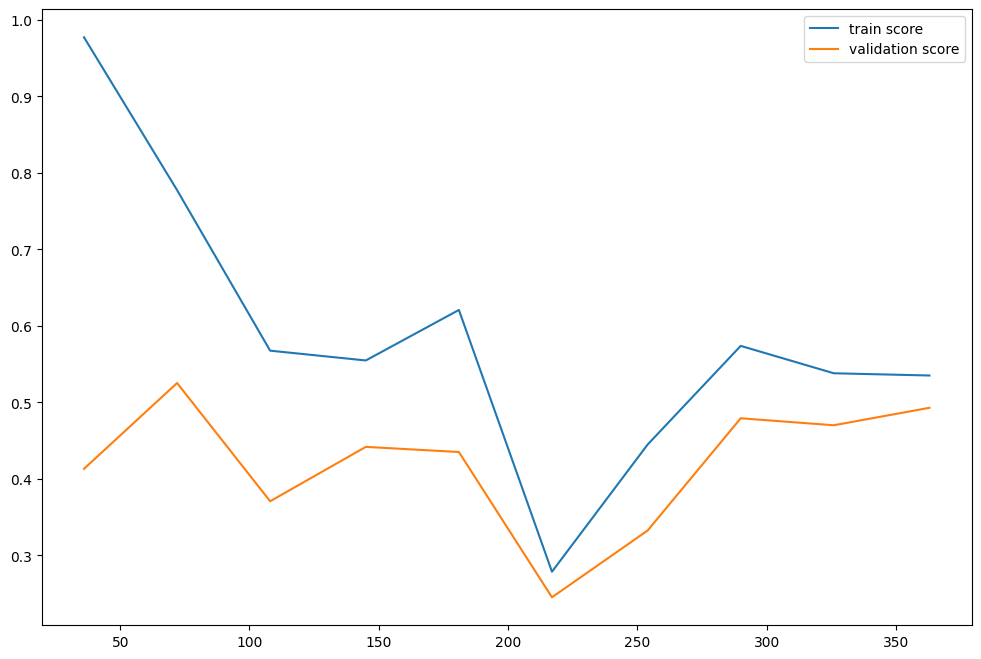

In [41]:
evaluation(grid.best_estimator_)

## **Precision Recall Curve**

In [48]:
from sklearn.metrics import precision_recall_curve

In [50]:
precision,recall,threshold=precision_recall_curve(y_test,grid.best_estimator_.decision_function(X_test))

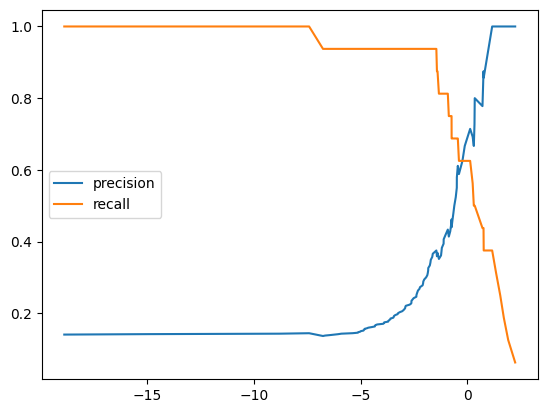

In [51]:
plt.plot(threshold, precision[:-1],label='precision')
plt.plot(threshold, recall[:-1],label='recall')
plt.legend()

In [54]:
def model_final(model,X,threshold=0):
    return model.decision_function(X)>threshold

In [55]:
y_pred=model_final(grid.best_estimator_,X_test,threshold=-1)

In [57]:
from sklearn.metrics import recall_score

In [56]:
f1_score(y_test,y_pred)

0.5652173913043479

In [59]:
recall_score(y_test,y_pred)

0.8125

## **Bilan**
**Notre objectif était** F1 0.5 et Recall 0.7

**Ici on a surpassé l'objectif** : F1 0.56 et Recall 0.81